# Project description

Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the amount of taxi orders for the next hour. Build a model for such a prediction.

The RMSE metric on the test set should not be more than 48.

## Preparation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg, ar_select_order
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima_model import ARMA
from pmdarima import auto_arima
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/datasets/taxi.csv')

In [ ]:
print(df.head())
print(df.info())

              datetime  num_orders
0  2018-03-01 00:00:00           9
1  2018-03-01 00:10:00          14
2  2018-03-01 00:20:00          28
3  2018-03-01 00:30:00          20
4  2018-03-01 00:40:00          32
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB
None


In [ ]:
df = df.rename(columns = 
               {'datetime': 'date_time'}).astype({'date_time': 'datetime64[ns]'})
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date_time   26496 non-null  datetime64[ns]
 1   num_orders  26496 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 414.1 KB
None


I added necessary libraries and imported the data set. i adjusted the type of datetime and changed to snake case format. i also checked the data set for over all structure and for null counts.

In [ ]:
df = df.set_index('date_time')
taxi_hourly = df['num_orders'].resample('H').sum()

In [ ]:
print(taxi_hourly.head())

date_time
2018-03-01 00:00:00    124
2018-03-01 01:00:00     85
2018-03-01 02:00:00     71
2018-03-01 03:00:00     66
2018-03-01 04:00:00     43
Freq: H, Name: num_orders, dtype: int64


i grouped the data  and resampled by the hour to get the total orders per hour instead of 10 minute intervals.

## Analysis

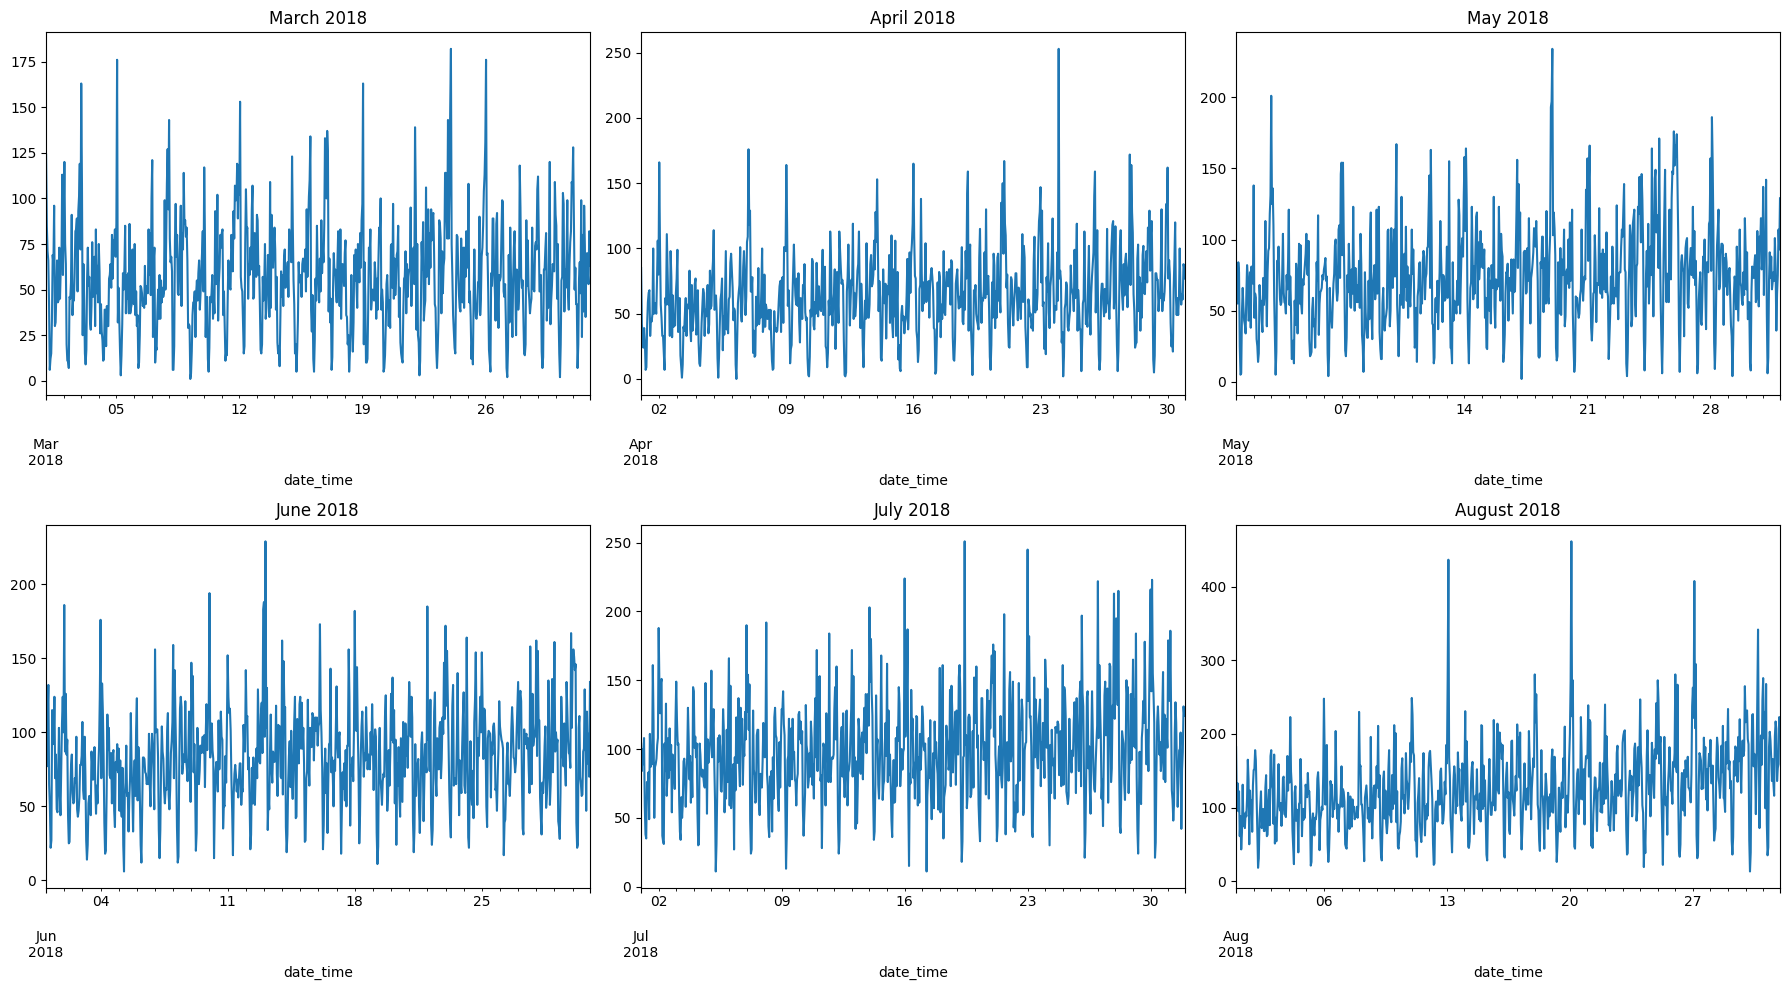

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

taxi_hourly['2018-03'].plot(ax = axes[0,0], title = 'March 2018')
taxi_hourly['2018-04'].plot(ax = axes[0,1], title = 'April 2018') 
taxi_hourly['2018-05'].plot(ax = axes[0,2], title = 'May 2018')
taxi_hourly['2018-06'].plot(ax = axes[1,0], title = 'June 2018')
taxi_hourly['2018-07'].plot(ax = axes[1,1], title = 'July 2018')
taxi_hourly['2018-08'].plot(ax = axes[1,2], title = 'August 2018')

plt.tight_layout()
plt.show()

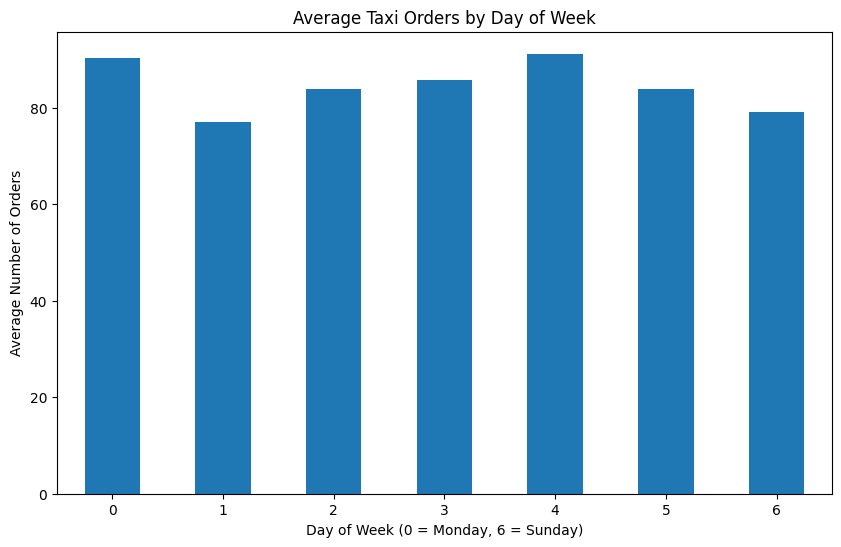

In [ ]:
daily_pattern = taxi_hourly.groupby(taxi_hourly.index.dayofweek).mean()

plt.figure(figsize = (10, 6))
daily_pattern.plot(kind = 'bar')
plt.title('Average Taxi Orders by Day of Week')
plt.xlabel('Day of Week (0 = Monday, 6 = Sunday)')
plt.ylabel('Average Number of Orders')
plt.xticks(rotation = 0)
plt.show()

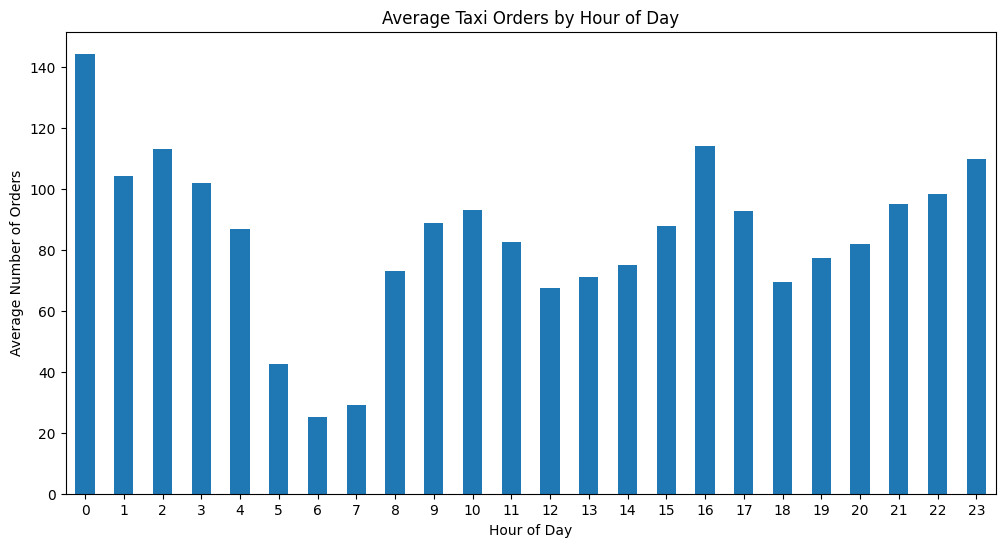

In [ ]:
hourly_pattern = taxi_hourly.groupby(taxi_hourly.index.hour).mean()

plt.figure(figsize = (12, 6))
hourly_pattern.plot(kind = 'bar')
plt.title('Average Taxi Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Number of Orders')
plt.xticks(rotation = 0)
plt.show()

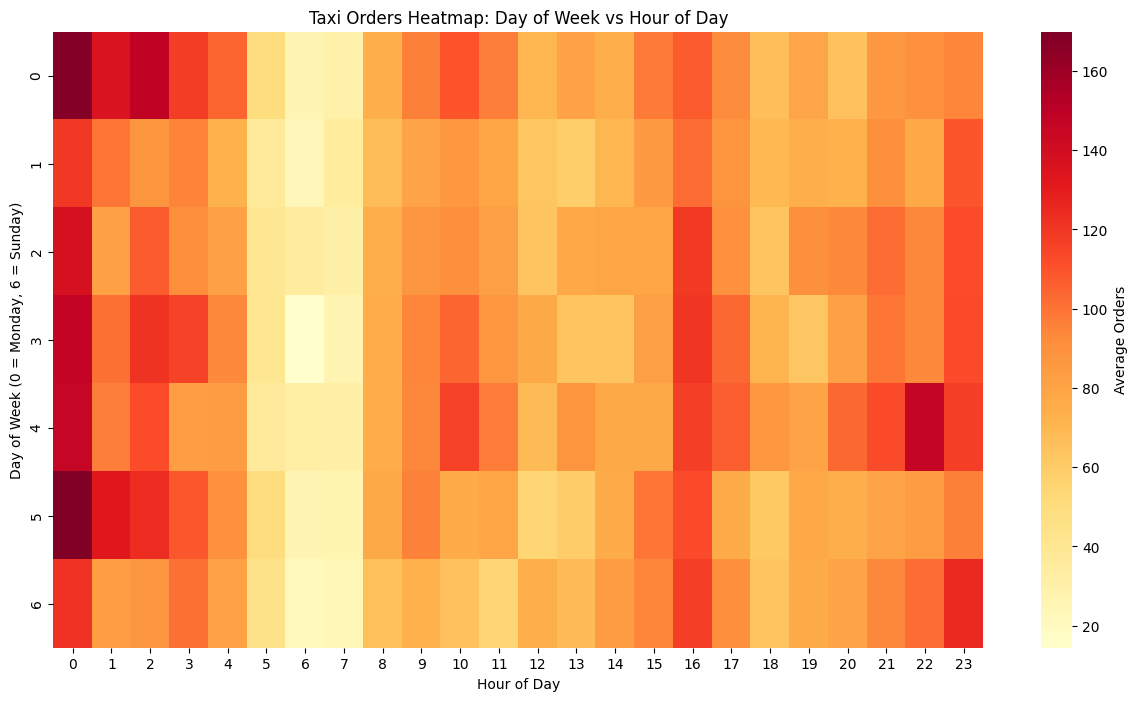

In [ ]:
hourly_by_day = taxi_hourly.groupby([taxi_hourly.index.dayofweek, taxi_hourly.index.hour]).mean().unstack()

plt.figure(figsize = (15, 8))
sns.heatmap(hourly_by_day, cmap = 'YlOrRd', cbar_kws = {'label': 'Average Orders'})
plt.title('Taxi Orders Heatmap: Day of Week vs Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week (0 = Monday, 6 = Sunday)')
plt.show()

From the first graph, we observe that there is no clear trend in taxi orders based on the day of the month, and the series appears to be non-stationary. The second graph shows that the average number of taxi orders per hour is relatively consistent across all days of the week. However, the third graph and the heat map reveal distinct patterns in the distribution of taxi orders: there are common peaks during the first hour and around the 16th hour, along with a noticeable lows between hours 5 and 7, regardless of the day of the week.

## Training

In [ ]:
train = taxi_hourly.iloc[:3974]
test = taxi_hourly.iloc[-442:]
train_size = int(len(train) * 0.8)
train_final = train[:train_size]
validation = train[train_size:]

In [ ]:
def create_time_features(data):
    """Create basic time-based features"""
    df = pd.DataFrame(index = data.index)
    df['target'] = data.values
    df['hour'] = data.index.hour
    df['day_of_week'] = data.index.dayofweek
    df['month'] = data.index.month
    df['day_of_month'] = data.index.day
    return df

def add_lag_features(df, data):
    """Add lag features to existing feature dataframe"""
    df['lag_1'] = data.shift(1)
    df['lag_24'] = data.shift(24)
    return df

i split my data into 90-10 split and then split the  90 into a 80-20 split for validation. i also created two functions to create time features. i also later added a function to add lag features to achieve better results in my models.

In [ ]:
train_features = create_time_features(train_final)
valid_features = create_time_features(validation)
test_features = create_time_features(test)

feature_cols_no_lag = ['hour', 'day_of_week', 'month', 'day_of_month']

X_train = train_features[feature_cols_no_lag]
X_valid = valid_features[feature_cols_no_lag]
X_test = test_features[feature_cols_no_lag]

Y_train = train_features['target']
Y_valid = valid_features['target']
Y_test = test_features['target']


In [ ]:
linear_model_no_lag = LinearRegression()
linear_model_no_lag.fit(X_train, Y_train)

LinearRegression()

In [ ]:
linear_pred_no_lag = linear_model_no_lag.predict(X_valid)
linear_rmse_no_lag = np.sqrt(mean_squared_error(Y_valid, linear_pred_no_lag))
print(f"RMSE: {linear_rmse_no_lag}")

RMSE: 43.46341864093035


In [ ]:
auto_model = auto_arima(train_final, seasonal = True, stepwise = True,
                           suppress_warnings = True, error_action=  'ignore',
                           max_p = 10, max_q = 10, max_order = 10)

print(auto_model.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3179
Model:               SARIMAX(0, 1, 1)   Log Likelihood              -15432.496
Date:                Mon, 09 Feb 2026   AIC                          30868.991
Time:                        05:03:31   BIC                          30881.119
Sample:                    03-01-2018   HQIC                         30873.341
                         - 07-11-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4706      0.014    -34.780      0.000      -0.497      -0.444
sigma2       966.9145     21.698     44.562      0.000     924.387    1009.442
Ljung-Box (L1) (Q):                  21.11   Jarque-

In [ ]:
auto_forecast = auto_model.predict(n_periods = 795)
auto_rmse = np.sqrt(mean_squared_error(validation, auto_forecast))
print(f"RMSE: {auto_rmse}")

RMSE: 44.02910619018604


In [ ]:
feature_cols = ['hour', 'day_of_week', 'month', 'day_of_month', 'lag_1', 'lag_24']

train_features = add_lag_features(train_features, train_final).dropna()
valid_features = add_lag_features(valid_features, validation).dropna()
test_features = add_lag_features(test_features, test).dropna()

x_train = train_features[feature_cols]
x_valid = valid_features[feature_cols]
x_test = test_features[feature_cols]

y_train = train_features['target']  
y_valid = valid_features['target'] 
y_test = test_features['target'] 

In [ ]:
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

LinearRegression()

In [ ]:
linear_pred = linear_model.predict(x_valid)
linear_rmse = np.sqrt(mean_squared_error(y_valid, linear_pred))
print(f"RMSE: {linear_rmse}")

RMSE: 34.12772053524998


In [ ]:
manual_arima = ARIMA(train_final, order = (2, 1, 1))
manual_arima_fit = manual_arima.fit()

In [ ]:
manual_forecast = manual_arima_fit.forecast(steps = len(validation))
manual_rmse = np.sqrt(mean_squared_error(validation, manual_forecast))
print(f"Manual ARIMA RMSE: {manual_rmse}")

Manual ARIMA RMSE: 45.04317300990315


after trying both models with and without lag features, i got better results with the lag features and linear model compared to both arima models that were within the threshold on validation, but not nearly as good as the linear model with lag features.

## Testing

In [ ]:
linear_pred_test = linear_model.predict(x_test)
linear_rmse_test = np.sqrt(mean_squared_error(y_test, linear_pred_test))
print(f"RMSE: {linear_rmse_test}")

RMSE: 47.43953946501325


After evaluating multiple models and tuning their parameters, I selected the linear regression model, as it achieved the lowest RMSE on the validation set (34.12). In comparison, the autoARIMA model produced an RMSE of 44.04, which is below the desired threshold of 48 but still underperformed relative to the linear regression model. Based on this performance, the linear regression model was chosen for evaluation on the test set, where it achieved an RMSE of 47.4395. This level of performance was made possible by the inclusion of lag features, which allowed the model to leverage information from the previous hour and the previous day when predicting the target variable.